<a href="https://colab.research.google.com/github/harshinisathya09-star/projects-/blob/main/project6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

In [ ]:
df = pd.read_csv("/content/Shopping Mall Customer Segmentation Data .csv")

In [ ]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


In [ ]:
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Annual Income,0
Spending Score,0


In [ ]:
df = df.dropna()

In [ ]:
df = df.drop_duplicates()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [ ]:
print(df.columns)

Index(['Customer ID', 'Age', 'Gender', 'Annual Income', 'Spending Score'], dtype='object')


In [ ]:
df.corr(numeric_only=True)

,Age,Gender,Annual Income,Spending Score
Age,1.000000,0.002034,0.004776,-0.008251
Gender,0.002034,1.000000,-0.003038,0.006703
Annual Income,0.004776,-0.003038,1.000000,0.003234
Spending Score,-0.008251,0.006703,0.003234,1.000000


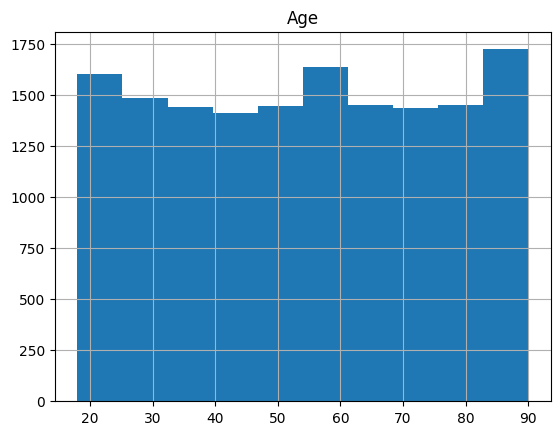

In [ ]:
df["Age"].hist()
plt.title("Age")
plt.show()

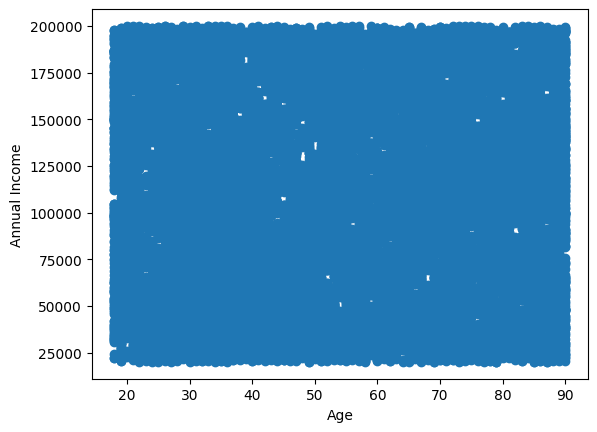

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df["Age"], df["Annual Income"])
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.show()

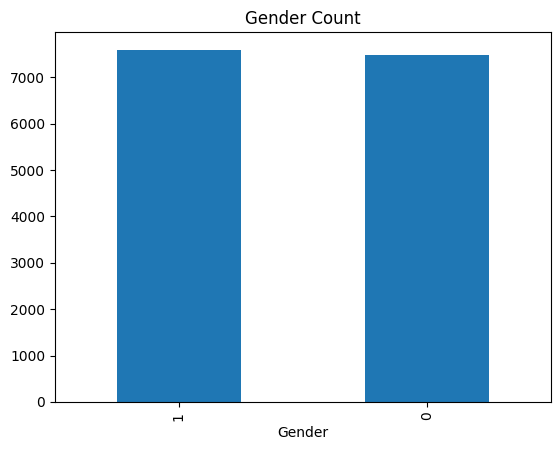

In [ ]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Count")
plt.show()

In [ ]:
X = df.drop("Gender", axis=1)
y = df["Gender"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(df.dtypes)

Customer ID       object
Age                int64
Gender             int64
Annual Income      int64
Spending Score     int64
dtype: object


In [ ]:
X = df.drop(["Customer ID", "Gender"], axis=1)
y = df["Gender"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [ ]:
import joblib
best_model = dt
joblib.dump(best_model, "best_model.pkl")
print("Best model saved successfully.")

Best model saved successfully.


In [ ]:
predictions = best_model.predict(X_test)
print(predictions)

[1 1 0 ... 0 1 1]
